<a href="https://colab.research.google.com/github/MO7AMEDNABIL/Sentiment_Analysis_Amazon_Reviews/blob/main/Sentiment_Analysis_Amanzon_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("/content/7817_1.csv")
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [4]:
df.isnull().sum()

,0
id,0
asins,0
brand,0
categories,0
colors,823
dateAdded,0
dateUpdated,0
dimension,1032
ean,699
keys,0


In [5]:
df['reviews.title'].head()

,reviews.title
0,"Paperwhite voyage, no regrets!"
1,One Simply Could Not Ask For More
2,Great for those that just want an e-reader
3,Love / Hate relationship
4,I LOVE IT


In [6]:
df["reviews.rating"].unique()

array([ 5.,  4., nan,  3.,  1.,  2.])

In [7]:
mode_rating = df["reviews.rating"].mode()[0]
df["reviews.rating"] = df["reviews.rating"].fillna(mode_rating)

In [8]:
df['reviews.rating'].isnull().sum()

np.int64(0)

In [9]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return 1   # Positive
    elif rating <= 2:
        return 0   # Negative
    else:
        return np.nan

df["sentiment"] = df["reviews.rating"].apply(rating_to_sentiment)

In [10]:
df = df.dropna(subset=["sentiment"])
df["sentiment"] = df["sentiment"].astype(int)

In [11]:
print(df["sentiment"].value_counts())
print(f"\nClass balance:\n{df['sentiment'].value_counts(normalize=True).mul(100).round(1)}%")

sentiment
1    1397
0      76
Name: count, dtype: int64

Class balance:
sentiment
1    94.8
0     5.2
Name: proportion, dtype: float64%


In [12]:
# Merge title + text for richer input
df["full_review"] = df["reviews.title"].fillna("") + " " + df["reviews.text"].fillna("")

In [13]:
df["full_review"].isnull().sum()

np.int64(0)

In [14]:
df['reviews.doRecommend'].unique()

array([nan, True, False], dtype=object)

In [15]:
# Simple text augmentation — shuffle words in negative reviews
import random

negative_reviews = df[df["sentiment"] == 0]["full_review"].tolist()

augmented = []
for review in negative_reviews:
    words = review.split()
    for _ in range(4):  # create 4 copies per review
        random.shuffle(words)
        augmented.append((" ".join(words), 0))

aug_df = pd.DataFrame(augmented, columns=["full_review", "sentiment"])
df_balanced = pd.concat([df, aug_df], ignore_index=True)

print(df_balanced["sentiment"].value_counts())

sentiment
1    1397
0     380
Name: count, dtype: int64


In [16]:
df_balanced["full_review"].head()

,full_review
0,"Paperwhite voyage, no regrets! I initially had..."
1,One Simply Could Not Ask For More Allow me to ...
2,Great for those that just want an e-reader I a...
3,Love / Hate relationship I bought one of the f...
4,I LOVE IT I have to say upfront - I don't like...


In [17]:
df_balanced[["full_review", "sentiment"]].head(25)

,full_review,sentiment
0,"Paperwhite voyage, no regrets! I initially had...",1
1,One Simply Could Not Ask For More Allow me to ...,1
2,Great for those that just want an e-reader I a...,1
3,Love / Hate relationship I bought one of the f...,1
4,I LOVE IT I have to say upfront - I don't like...,1
5,Great device for reading. 8 people found this ...,1
6,One Simply Could Not Ask For More 28 people fo...,1
7,Definitely better than the previous generation...,1
8,"Paperwhite voyage, no regrets! 16 people found...",1
9,Great for those that just want an e-reader 19 ...,1


In [18]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00


In [19]:
import re
import contractions


def clean_reviews_text(text):

    text = contractions.fix(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#(\w+)', r'\1', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_balanced['full_review']= df_balanced ['full_review'].apply(clean_reviews_text)
df_balanced['full_review'].head()

,full_review
0,paperwhite voyage no regrets i initially had t...
1,one simply could not ask for more allow me to ...
2,great for those that just want an ereader i am...
3,love hate relationship i bought one of the fir...
4,i love it i have to say upfront i do not like ...


In [20]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [21]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download("stopwords")
nltk.download("punkt")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
keep_words = {"not", "no", "never", "neither", "nor", "barely", "hardly"}
stop_words = stop_words - keep_words

def lemmatize_text(text):
    tokens = word_tokenize(text)
    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    return " ".join(lemmatized_tokens)

df_balanced['full_review'] = df_balanced['full_review'].apply(lemmatize_text)
df_balanced['full_review'].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,full_review
0,paperwhite voyage no regret initially trouble ...
1,one simply could not ask allow preface little ...
2,great want ereader enjoying far great reading ...
3,love hate relationship bought one first paperw...
4,love say upfront not like coroporate hermetica...


In [22]:
lemmatizer1 = WordNetLemmatizer()
lemmatizer1.lemmatize("children")

'child'

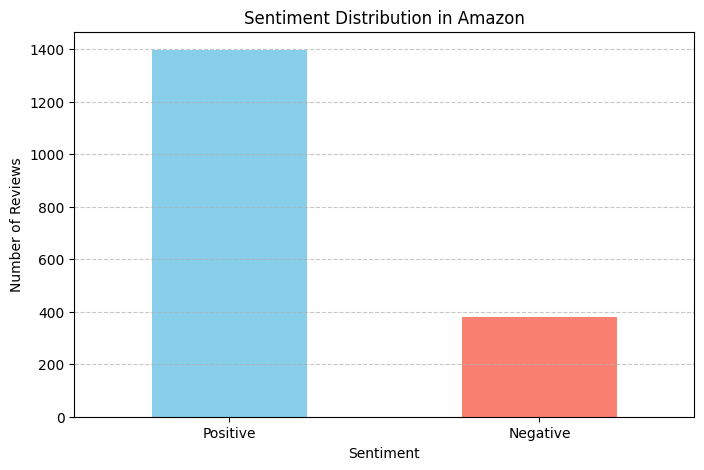

In [23]:
sentiment_counts = df_balanced['sentiment'].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar', color=['skyblue', 'salmon'])

plt.title("Sentiment Distribution in Amazon")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(ticks=[1, 0], labels=["Negative","Positive"], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df_balanced["full_review"]
y = df_balanced["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

Train size: 1421
Test size:  356


In [25]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

In [26]:
model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [27]:
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.89      1.00      0.94        76
    Positive       1.00      0.97      0.98       280

    accuracy                           0.97       356
   macro avg       0.95      0.98      0.96       356
weighted avg       0.98      0.97      0.98       356



In [28]:
import re
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))
keep_words = {"not", "no", "never", "neither", "nor", "barely", "hardly"}
stop_words = stop_words - keep_words

def clean_text(text):
    # 1. Fix contractions → "don't" to "do not"
    text = contractions.fix(text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 4. Remove mentions
    text = re.sub(r'@\w+', '', text)

    # 5. Remove hashtag symbol but keep word
    text = re.sub(r'#(\w+)', r'\1', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Remove stopwords + lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [29]:
def predict_sentiment(text):

    text_clean = clean_text(text)

    # Vectorize using trained vectorizer
    text_tfidf = vectorizer.transform([text_clean])

    #Predict
    prediction = model.predict(text_tfidf)[0]
    probability = model.predict_proba(text_tfidf)[0]

    label = "Positive ✅" if prediction == 1 else "Negative ❌"
    confidence = round(max(probability) * 100, 2)

    print(f"Review    : {text}")
    print(f"Cleaned   : {text_clean}")
    print(f"Sentiment : {label}")
    print(f"Confidence: {confidence}%")


review = input("Enter your review: ")
predict_sentiment(review)

Enter your review: love this product
Review    : love this product
Cleaned   : love product
Sentiment : Positive ✅
Confidence: 86.2%


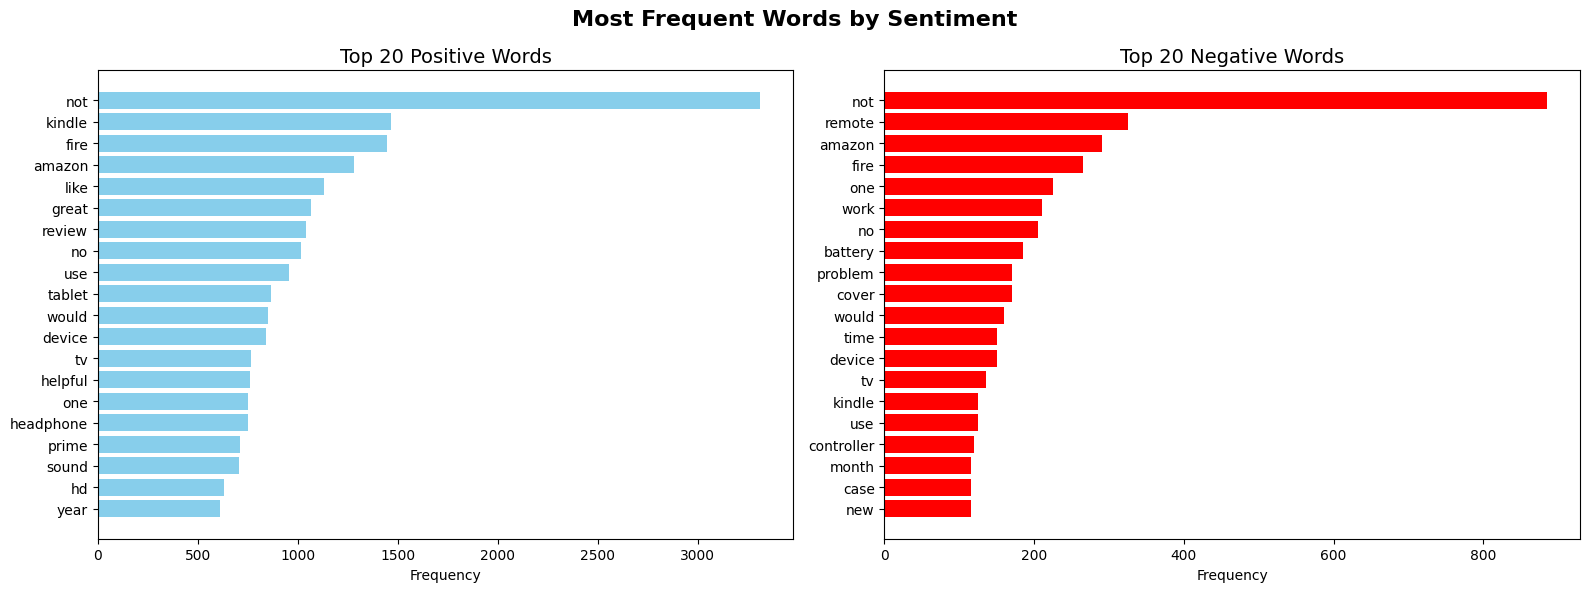

In [31]:
from collections import Counter
import matplotlib.pyplot as plt

# Separate positive and negative reviews
positive_reviews = df_balanced[df_balanced["sentiment"] == 1]["full_review"]
negative_reviews = df_balanced[df_balanced["sentiment"] == 0]["full_review"]


def get_top_words(reviews, n=20):
    all_words = " ".join(reviews).split()
    return Counter(all_words).most_common(n)

top_positive = get_top_words(positive_reviews)
top_negative = get_top_words(negative_reviews)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive words
pos_words, pos_counts = zip(*top_positive)
axes[0].barh(pos_words, pos_counts, color="skyblue")
axes[0].set_title("Top 20 Positive Words", fontsize=14)
axes[0].set_xlabel("Frequency")
axes[0].invert_yaxis()

# Negative words
neg_words, neg_counts = zip(*top_negative)
axes[1].barh(neg_words, neg_counts, color="red")
axes[1].set_title("Top 20 Negative Words", fontsize=14)
axes[1].set_xlabel("Frequency")
axes[1].invert_yaxis()

plt.suptitle("Most Frequent Words by Sentiment", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("=" * 50)
print("NAIVE BAYES:")
print("=" * 50)
print(classification_report(y_test, nb_pred, target_names=["Negative", "Positive"]))

print("=" * 50)
print("LOGISTIC REGRESSION:")
print("=" * 50)
print(classification_report(y_test, y_pred , target_names=["Negative", "Positive"]))

NAIVE BAYES:
              precision    recall  f1-score   support

    Negative       0.98      0.62      0.76        76
    Positive       0.91      1.00      0.95       280

    accuracy                           0.92       356
   macro avg       0.94      0.81      0.85       356
weighted avg       0.92      0.92      0.91       356

LOGISTIC REGRESSION:
              precision    recall  f1-score   support

    Negative       0.89      1.00      0.94        76
    Positive       1.00      0.97      0.98       280

    accuracy                           0.97       356
   macro avg       0.95      0.98      0.96       356
weighted avg       0.98      0.97      0.98       356

